Got the DataSet from kaggle -> https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data,  
And this consists of 4 huge .txt files which hold about 25 mil rows of data,  
Also a movie_titles.csv file representin the meta data, used in gen part of this project  
For computational Eff. we take one the txt files (say 2, no reason) and filter it down to (1~2) mil rows approx  

In [24]:
import pandas as pd
import os

path = os.path.join("..", "final_data")  # Avoids OS issues later on
os.makedirs(path, exist_ok=True)

# expected to store the dataset inside a directory named data.. 
txtFile_path = "../data/combined_data_2.txt"
df = pd.read_csv(txtFile_path, header=None, names=("User_ID", "Rating", "Date"))

"""
The txt file has data as:

MovieID1:
CustomerID11,Date11
CustomerID12,Date12
....
MovieID2:
CustomerID21,Date21
CustomerID22,Date22    

so the Movie ID columns have NaN in Ratng as well as Date columns.
"""
None

In [25]:
print(df.dtypes)
df.head()

User_ID        str
Rating     float64
Date           str
dtype: object


,User_ID,Rating,Date
0,4500:,NaN,NaN
1,2532865,4.0,2005-07-26
2,573364,3.0,2005-06-20
3,1696725,3.0,2004-02-27
4,1253431,3.0,2004-03-31


In [26]:
df['Rating'].isna().sum(), df['Date'].isna().sum()
# making sure there r no missing values.

(np.int64(4711), np.int64(4711))

In [27]:
# clean Movie ID's and create a new column to hold the respective movie id

# df with movie id based rows only
movie_rows = df[df["User_ID"].str.endswith(":")]
movie_rows

,User_ID,Rating,Date
0,4500:,NaN,NaN
259,4501:,NaN,NaN
855,4502:,NaN,NaN
960,4503:,NaN,NaN
2740,4504:,NaN,NaN
...,...,...,...
26957496,9206:,NaN,NaN
26959947,9207:,NaN,NaN
26961403,9208:,NaN,NaN
26980373,9209:,NaN,NaN


In [28]:
# Introduce the Movie_ID column
df["Movie_ID"] = movie_rows["User_ID"].str.replace(":", "").astype(int)

# forwardfill it, 
df['Movie_ID'] = df['Movie_ID'].ffill()

# drop those irrel movie id rows
df = df.drop(movie_rows.index)

In [29]:
# reset the index counter..
df = df.reset_index(drop=True)

In [30]:
df.dtypes

User_ID         str
Rating      float64
Date            str
Movie_ID    float64
dtype: object

For memory efficiency

In [31]:
# change ni data types.
df["User_ID"] = df["User_ID"].astype(int)
df["Rating"] = df["Rating"].astype(int)
df["Movie_ID"] = df["Movie_ID"].astype(int)

# Droppin the date column since I have choosen SVD and Item-Based Collaborative Filtering models to compare
# these look only at the user, Movie, and ratings, (HUge limitation on time_data removal)
df = df.drop(columns=["Date"])

df.dtypes

User_ID     int64
Rating      int64
Movie_ID    int64
dtype: object

proccessed Data Frame, ready to be the 'netflix_subset.csv', which goes into location final_data

In [32]:
df

,User_ID,Rating,Movie_ID
0,2532865,4,4500
1,573364,3,4500
2,1696725,3,4500
3,1253431,3,4500
4,1265574,2,4500
...,...,...,...
26977586,2420260,1,9210
26977587,761176,3,9210
26977588,459277,3,9210
26977589,2407365,4,9210


In [33]:
# temp = df.copy()
# For tweaking purposes

In [34]:
movie_counts = df['Movie_ID'].value_counts()
movie_counts

Movie_ID
5317    232944
6287    193295
6972    171991
6037    158601
5496    155714
         ...  
8964        25
4711        22
8146        14
4806        13
6256        10
Name: count, Length: 4711, dtype: int64

In [35]:
movie_counts = df['Movie_ID'].value_counts()

print(movie_counts.describe(),'\n')
print("Top 1% movies cover   :", round(movie_counts.nlargest(int(len(movie_counts)*0.01)).sum() / len(df) * 100, 3), "% of all ratings")
print("Top 10% movies cover  :", round(movie_counts.nlargest(int(len(movie_counts)*0.10)).sum() / len(df) * 100, 3), "% of all ratings")
print("Bottom 50% movies cover:", round(movie_counts.nsmallest(int(len(movie_counts)*0.50)).sum() / len(df) * 100, 3), "% of all ratings")

count      4711.000000
mean       5726.510507
std       16672.239244
min          10.000000
25%         183.000000
50%         554.000000
75%        2857.000000
max      232944.000000
Name: count, dtype: float64 

Top 1% movies cover   : 21.288 % of all ratings
Top 10% movies cover  : 75.836 % of all ratings
Bottom 50% movies cover: 1.975 % of all ratings


from above results the sparsity issue and distribution can be clearly seen.

In [36]:
import numpy as np

movie_counts = df['Movie_ID'].value_counts()

# Log-scale bins: 10-200, 200-2000, 2000-20000, 20000+
bins = [0, 200, 2000, 20000, float('inf')]
labels = ['long_tail', 'niche', 'mid', 'popular']

tier_map = pd.cut(movie_counts, bins=bins, labels=labels)
df['pop_tier'] = df['Movie_ID'].map(tier_map)

print(df['pop_tier'].value_counts(), '\n')
print("Ratings per tier:")
print(df.groupby('pop_tier', observed=True).size())

pop_tier
popular      18359005
mid           7061511
niche         1387092
long_tail      169983
Name: count, dtype: int64 

Ratings per tier:
pop_tier
long_tail      169983
niche         1387092
mid           7061511
popular      18359005
dtype: int64


The dataset suffers from a severe longtail distribution, a small number of blockbuster movies dominate the majority of ratings while thousands of niche titles have very few interactions.
To solve this, we analyze the raw distri..

Top 10% of movies take about 76% of all ratings
Bottom 50% of movies account for only 2% of all ratings

A simple random sample or linear binning would fail here because it would replicate the same skew at smaller scale,
the model would essentially only learn from popular movies and recommend the same blockbusters to everyone no matter their own tastes

To solve this, we apply log-scale popularity tiering that is the binning of movies by rating count on a logarithmic scale rather than a linear one
this mantains the sparsity just like the original data Set.

In [37]:
import numpy as np

min_user_ratings = 5
min_movie_ratings = 10


def iterative_filter(dataFrame, min_user, min_movie, iters):
    for i in range(iters):
        prev_len = len(dataFrame)
        if prev_len == 0:
            break
        user_counts = dataFrame["User_ID"].value_counts()
        movie_counts = dataFrame["Movie_ID"].value_counts()

        dataFrame = dataFrame[
            dataFrame["User_ID"].isin(user_counts[user_counts >= min_user].index)
            & dataFrame["Movie_ID"].isin(movie_counts[movie_counts >= min_movie].index)
        ]
        if len(dataFrame) == prev_len:
            break
    return dataFrame


# Filter first on raw df
print("applying filtering on data")
df = iterative_filter(df, min_user_ratings, min_movie_ratings, iters=10)
print(f"after this filter: {len(df):,} rows")

# Now tiering and sample on the clean data
movie_counts = df["Movie_ID"].value_counts()
bins = [0, 200, 2000, 20000, float("inf")]
labels = ["long_tail", "niche", "mid", "popular"]

df["pop_tier"] = df["Movie_ID"].map(pd.cut(movie_counts, bins=bins, labels=labels))

# here we do the stratified-sampling...(divide and sample from each grp individually)
tier_targets = {
    "popular"  : 600_000,
    "mid"      : 700_000,
    "niche"    : 500_000,
    "long_tail": 169_983,
}

sampled_tiers = list()
for tier, target in tier_targets.items():
    tier_df = df[df["pop_tier"] == tier]
    n = min(len(tier_df), target)
    if n > 0:
        sampled_tiers.append(tier_df.sample(n=n, random_state=42))

df = pd.concat(sampled_tiers).reset_index(drop=True)
df = df.drop(columns=["pop_tier"])

# Stats
n_users  = df["User_ID"].nunique()
n_movies = df["Movie_ID"].nunique()
sparsity = (1 - len(df) / (n_users * n_movies)) * 100

print("\n" + "=" * 40)
print(f"Projected rows : {len(df):,}")
print(f"Unique users   : {n_users:,}")
print(f"Unique movies  : {n_movies:,}")
print(f"Sparsity       : {sparsity:.4f}%")
print("=" * 40)

applying filtering on data
after this filter: 26,863,473 rows

Projected rows : 1,969,321
Unique users   : 326,833
Unique movies  : 4,711
Sparsity       : 99.8721%


In [38]:
df

,User_ID,Rating,Movie_ID
0,1327492,4,5788
1,2041551,5,6449
2,2618551,4,8832
3,480115,4,6599
4,1639981,5,8627
...,...,...,...
1969316,716874,3,7894
1969317,82742,2,7410
1969318,2163705,5,8236
1969319,305344,2,8642


#### I have done my best to use the computational efficiency, currently on this program basis it alredy takes up decently heavy usage on ram..!

Finally we save this into the final_data directory made in the first block of notebook

In [39]:
path = "../final_data/netflix_final.csv"
path

'../final_data/netflix_final.csv'

In [40]:
df.to_csv(path, index=False)
print("final csv final now exists in final_data folder")

final csv final now exists in final_data folder


## QUICK FINAL ANALYSIS

In [41]:
import matplotlib.pyplot as plt

print("Safely parsing movie_titles.csv...")

# Using a customized parser to handle titles containing commas seamlessly
# since some of the movie names itself contain those ',''s in their titles.
movie_records = []
with open("../data/movie_titles.csv", "r", encoding="ISO-8859-1") as f:
    for line in f:
        # Split on the first two commas only: [Movie_ID, Year, Title...]
        parts = line.strip().split(",", 2)
        if len(parts) == 3:
            movie_records.append(parts)

# Construct our clean metadata dataframe
df_meta = pd.DataFrame(movie_records, columns=["Movie_ID", "Year", "Title"])

# Convert Movie_ID to matching type (int64) for a flawless merge
df_meta["Movie_ID"] = df_meta["Movie_ID"].astype(int)

# Merge back with your clean, self-stratified df
df_eda = pd.merge(df, df_meta, on="Movie_ID", how="inner")


Safely parsing movie_titles.csv...


Calculating Rating Distributions...


/tmp/ipykernel_13975/2866517077.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")


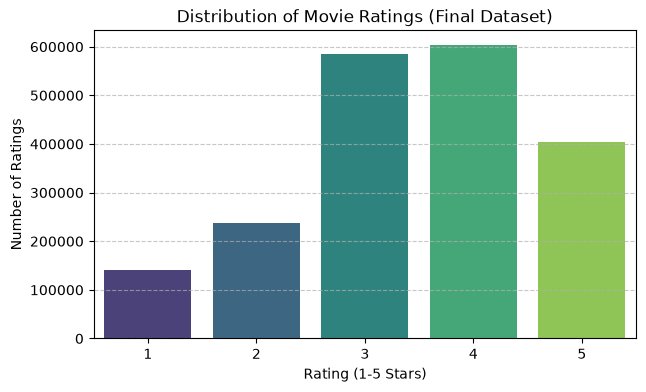

Rating Shares:
  1 Stars: 7.13%
  2 Stars: 12.06%
  3 Stars: 29.69%
  4 Stars: 30.63%
  5 Stars: 20.49%


In [42]:
import seaborn as sns

# --- Rating Distributions ---
print("Calculating Rating Distributions...")
rating_counts = df_eda["Rating"].value_counts().sort_index()
rating_pct = (rating_counts / len(df_eda)) * 100

plt.figure(figsize=(7, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")
plt.title("Distribution of Movie Ratings (Final Dataset)")
plt.xlabel("Rating (1-5 Stars)")
plt.ylabel("Number of Ratings")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print("Rating Shares:")
for rate, pct in zip(rating_counts.index, rating_pct):
    print(f"  {rate} Stars: {pct:.2f}%")


 Analyzing User Activity Patterns...
Average ratings per user: 6.0
Most active user profile : 2114 ratings
Least active user profile: 1 ratings


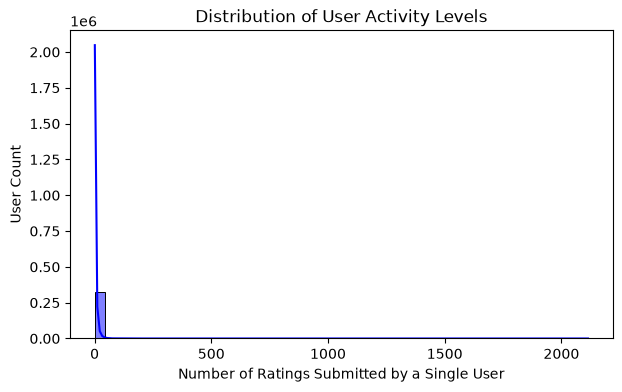

In [43]:

# --- User Activity Patterns ---
print("\n Analyzing User Activity Patterns...")
user_activity = df_eda["User_ID"].value_counts()
print(f"Average ratings per user: {user_activity.mean():.1f}")
print(f"Most active user profile : {user_activity.max()} ratings")
print(f"Least active user profile: {user_activity.min()} ratings")

plt.figure(figsize=(7, 4))
sns.histplot(user_activity, bins=50, kde=True, color="blue")
plt.title("Distribution of User Activity Levels")
plt.xlabel("Number of Ratings Submitted by a Single User")
plt.ylabel("User Count")
plt.show()

In [44]:
# -- Content Popularity Trends ---
print("\n The Popularity Trends...")
movie_popularity = df_eda.groupby(["Movie_ID", "Title", "Year"]).size().reset_index(name="Rating_Count")

print("\n TOP 5 MOST POPULAR MOVIES IN OUR SAMPLE:")
print(movie_popularity.nlargest(5, "Rating_Count")[["Title", "Year", "Rating_Count"]].to_string(index=False))

print("\n TOP 5 LONGEST-TAIL (NICHE) MOVIES RETAINED:")
print(movie_popularity.nsmallest(5, "Rating_Count")[["Title", "Year", "Rating_Count"]].to_string(index=False))


 The Popularity Trends...

 TOP 5 MOST POPULAR MOVIES IN OUR SAMPLE:
              Title Year  Rating_Count
  Miss Congeniality 2000          7441
       Pretty Woman 1990          6376
         Armageddon 1998          5662
The Bourne Identity 2002          5139
           I, Robot 2004          5099

 TOP 5 LONGEST-TAIL (NICHE) MOVIES RETAINED:
                                             Title Year  Rating_Count
                       Larryboy and the Rumor Weed 1999            10
                            Dune: Extended Edition 1984            13
The Land Before Time VI: The Secret of Saurus Rock 1998            14
                  Journey Into Amazing Caves: IMAX 2001            22
                       Trailer Park Boys: Season 4 2003            25


In [45]:
# --- Data Sparsity Characteristics ---
print("\n Displaying Matrix Sparsity Metrics...")
n_users = df_eda["User_ID"].nunique()
n_movies = df_eda["Movie_ID"].nunique()
sparsity = (1 - len(df_eda) / (n_users * n_movies)) * 100

print(f"Total Interacting Nodes : {len(df_eda):,}")
print(f"User-Item Matrix Shape  : {n_users:,} Users x {n_movies:,} Movies")
print(f"Calculated Data Sparsity: {sparsity:.4f}%")
print("="*40)


 Displaying Matrix Sparsity Metrics...
Total Interacting Nodes : 1,969,321
User-Item Matrix Shape  : 326,833 Users x 4,711 Movies
Calculated Data Sparsity: 99.8721%
